# Step-by-step preprocessing: synthetic domain and experimental domain

This notebook **does not modify or overwrite** the original `.h5` files:
- `simulation_dataset_V2.h5` (domain A, FEM simulation)
- `measurements_database_robot_V2.h5` (domain B, robot measurements)

It only **reads** them and writes two **new** files:
- `synthetic_dataset_6x12.h5`
- `experimental_dataset_6x12.h5`

Each cell performs a single pipeline step and shows a visualization so you can confirm the result is as expected before moving to the next cell.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from data_io import (
    AB_MASK,
    compress_ab_pairs,
    compress_ab_pairs_list,
    expand_ab_pairs,
    find_analogous_sample,
    get_experimental_sample_before_after,
    load_experimental_domain,
    load_synthetic_domain,
    save_compressed_dataset_h5,
)

# --- PATHS (adjust if needed) ---
# V2: main_generate_simulation_dataset.m fixed a sign bug in how the target
# was placed on the FEM mesh (not just a metadata/labeling issue -- the
# simulated Esc field itself was mis-positioned before this fix). Verified
# empirically: with this V2 file, the IDENTITY position match (no transform)
# is the best one against measurements_database_robot_V2.h5 (which is
# unchanged) -- see STEP 1b below.
SIM_H5_PATH = ("/Users/felipemedina/Desktop/POLITO/Micriwave Brain/"
               "OSMI---Open-Source-Microwave-Imaging-main/Examples/"
               "Head_imaging/results/simulation_dataset_V2.h5")
ROBOT_H5_PATH = ("/Users/felipemedina/Desktop/POLITO/Micriwave Brain/"
                 "Robot_Acquisition/measurements_database_robot_V2.h5")
FREQ_HZ = 1.3e9

# acq_1125 to acq_1142 (18 acquisitions, all 'target', Target 2) were flagged
# as corrupted/invalid -- excluded entirely (not used as target, not used as
# background reference either) from the experimental domain.
EXCLUDE_ACQ_NUMBERS = range(1125, 1143)

# --- OUTPUTS (NEW files, the originals are never touched) ---
OUT_SYNTHETIC_H5 = "./synthetic_dataset_6x12.h5"
OUT_EXPERIMENTAL_H5 = "./experimental_dataset_6x12.h5"

## Utilities: visualization and dataset summary

- `show_matrix`: plots the real / imaginary part of a matrix (12x12 or 6x12).
- `show_before_after`: plots two matrices (before / after) in a 2xN grid, to compare the effect of background subtraction.
- `summarize_dataset`: counts how many samples there are and how they break down by target type and permittivity.

In [10]:
from collections import Counter


def show_matrix(mat, title=""):
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    im0 = ax[0].matshow(np.real(mat))
    ax[0].set_title(f"{title} - Re")
    plt.colorbar(im0, ax=ax[0])
    im1 = ax[1].matshow(np.imag(mat))
    ax[1].set_title(f"{title} - Im")
    plt.colorbar(im1, ax=ax[1])
    fig.tight_layout()
    plt.show()


def show_before_after(before, after, label_before, label_after):
    """2x2 grid: rows = before/after, columns = Re/Im."""
    fig, ax = plt.subplots(2, 2, figsize=(9, 8))
    im00 = ax[0, 0].matshow(np.real(before))
    ax[0, 0].set_title(f"{label_before} - Re")
    plt.colorbar(im00, ax=ax[0, 0])
    im01 = ax[0, 1].matshow(np.imag(before))
    ax[0, 1].set_title(f"{label_before} - Im")
    plt.colorbar(im01, ax=ax[0, 1])
    im10 = ax[1, 0].matshow(np.real(after))
    ax[1, 0].set_title(f"{label_after} - Re")
    plt.colorbar(im10, ax=ax[1, 0])
    im11 = ax[1, 1].matshow(np.imag(after))
    ax[1, 1].set_title(f"{label_after} - Im")
    plt.colorbar(im11, ax=ax[1, 1])
    fig.tight_layout()
    plt.show()


def summarize_dataset(meta_list, domain_name):
    """Prints how many samples there are and their breakdown by target_type / eps."""
    print(f"--- Dataset summary '{domain_name}' ---")
    print(f"Total samples: {len(meta_list)}")

    tt_counts = Counter(m.get("target_type", "NA") for m in meta_list)
    print("By target_type:")
    for k, v in sorted(tt_counts.items()):
        print(f"  {k}: {v}")

    eps_counts = Counter(m.get("target_eps_label", "NA") for m in meta_list)
    print("By target_eps_label:")
    for k, v in sorted(eps_counts.items()):
        print(f"  {k}: {v}")

---
## STEP 1 -- Load both domains (raw)

Both full domains are loaded first (not yet compressed) so that, in the next step, we can look for one sample from each that is comparable to the other.

- Domain A: `simulation_dataset.h5` already contains the differential field `Esc = E_total - E_background` (computed inside `main_generate_simulation_dataset.m`, line 365), and already comes with the A<->B mask applied. `load_synthetic_domain` only reads it, it does not subtract anything.
- Domain B: `measurements_database_robot_V2.h5` contains the raw TOTAL field, unsubtracted. `load_experimental_domain` builds the differential `dS = S_target - S_previous_healthy` (the healthy acquisition immediately before it, by acquisition index) and picks the frequency closest to `FREQ_HZ`. **The subtraction happens inside this function, in the cell below** -- everything that follows (visualization, compression, saving) already operates on the differential, never on the raw total field. It also excludes `EXCLUDE_ACQ_NUMBERS` (acq_1125-acq_1142) entirely, flagged as corrupted/invalid measurements -- they are skipped both as targets and as background references.

In [11]:
A_raw_list, A_meta = load_synthetic_domain(SIM_H5_PATH)
summarize_dataset(A_meta, "synthetic (raw, 12x12, before compression)")

[data_io] Dominio A (sintetico): 1216 muestras leidas de '/Users/felipemedina/Desktop/POLITO/Micriwave Brain/OSMI---Open-Source-Microwave-Imaging-main/Examples/Head_imaging/results/simulation_dataset.h5'
--- Resumen dataset 'synthetic (crudo, 12x12, antes de comprimir)' ---
Total de muestras: 1216
Por target_type:
  Target 1 (30x20mm): 672
  Target 2 (60x50mm): 416
  Target 3 (110x80mm): 128
Por target_eps_label:
  Hem 1  (eps = 63.69): 304
  Hem 2  (eps = 77.7): 304
  Isc 1  (eps = 37.47): 304
  Isc 2  (eps = 15.1): 304


In [12]:
B_raw_list, B_meta = load_experimental_domain(
    ROBOT_H5_PATH, freq_hz=FREQ_HZ, exclude_acq_numbers=EXCLUDE_ACQ_NUMBERS)
summarize_dataset(B_meta, "experimental (already differential, 12x12, before compression)")

[data_io] Dominio B (experimental): 1239 muestras diferenciales construidas de '/Users/felipemedina/Desktop/POLITO/Micriwave Brain/Robot_Acquisition/measurements_database_robot_V2.h5' (f = 1.300 GHz)
--- Resumen dataset 'experimental (ya diferencial, 12x12, antes de comprimir)' ---
Total de muestras: 1239
Por target_type:
  Target 1 (30×20mm): 677
  Target 2 (60×50mm): 434
  Target 3 (110×80mm): 128
Por target_eps_label:
  Hem 1  (eps = 52.0): 325
  Hem 2  (eps = 58.0): 306
  Isc 1  (eps = 72.0): 304
  Isc 2  (eps = 80.0): 304


### STEP 1b -- Pick an "analogous" sample in both domains

So that the A and B visualizations are comparable, we look for a sample from each domain that matches on:
- **target size** (Target 1 / 2 / 3),
- **position** (`pos_x_mm`, `pos_y_mm`) -- with `simulation_dataset_V2.h5`, positions from domain A and domain B correspond DIRECTLY (identity, no transform needed). This was verified empirically: comparing raw (uncalibrated) ΔS/ΔE patterns, identity gives more pattern similarity than any of the 8 candidate sign/swap transforms tried (including the `(-x,-y)` correction that was needed with the OLD `simulation_dataset.h5`), and finds an exact match for all 1239/1239 domain B samples (vs 1173/1239 with the old file + correction). See `experimental_to_synthetic_position` docstring in `data_io.py` for the history.
- **liquid group** (Hem1 / Hem2 / Isc1 / Isc2) -- comparing ONLY the label text (`target_eps_label`), not the numeric value of `target_epsilon_re` (the simulation and the robot use slightly different permittivities for the "same" label, e.g. Hem 1 = eps 63.69 in the simulation vs eps 52.0 on the robot).

In [13]:
match = find_analogous_sample(A_meta, B_meta, pos_tol_mm=1.0, match_position=True)
if match is None:
    print("[WARN] No exact position match; relaxing the criterion to size+liquid only...")
    match = find_analogous_sample(A_meta, B_meta, match_position=False)
if match is None:
    print("[WARN] No analogous sample found; using index 0 in both domains.")
    idx_ejemplo_A, idx_ejemplo_B = 0, 0
else:
    idx_ejemplo_A, idx_ejemplo_B = match

print(f"Sample chosen in domain A -> index {idx_ejemplo_A}: {A_meta[idx_ejemplo_A]}")
print(f"Sample chosen in domain B -> index {idx_ejemplo_B}: {B_meta[idx_ejemplo_B]}")

Muestra elegida en dominio A -> indice 0: {'target_type': 'Target 1 (30x20mm)', 'target_epsilon_re': 63.69, 'target_eps_label': 'Hem 1  (eps = 63.69)', 'pos_x_mm': -50.0, 'pos_y_mm': -40.0, 'rotation_deg': -45.0}
Muestra elegida en dominio B -> indice 6: {'target_type': 'Target 1 (30×20mm)', 'target_epsilon_re': 52.0, 'target_eps_label': 'Hem 1  (eps = 52.0)', 'pos_x_mm': -50.0, 'pos_y_mm': -40.0, 'rotation_deg': 0.0, 'timestamp': '2026-06-29 10:26:09'}


---
## STEP 2 -- Domain A: visual verification and compression

### Visual check: 12x12 matrix (before compression)

The top-left block (A-A) and the bottom-right block (B-B) should be clearly zero; only the cross blocks (top-right and bottom-left) should have values.

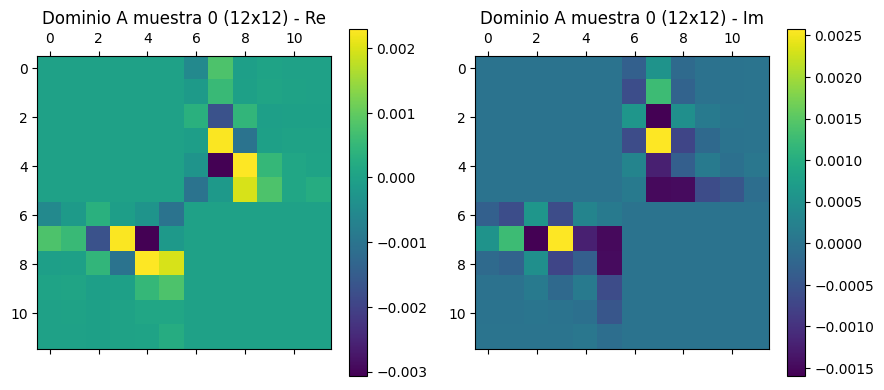

Entradas no-cero: 72 (esperado: 72)


In [14]:
show_matrix(A_raw_list[idx_ejemplo_A], title=f"Domain A sample {idx_ejemplo_A} (12x12)")

n_no_cero = np.sum(np.abs(A_raw_list[idx_ejemplo_A]) > 0)
print(f"Nonzero entries: {n_no_cero} (expected: 72)")
assert n_no_cero <= 72, "There are more nonzero entries than the 72 physically valid ones"

### STEP 2b -- Compress to 6x12 (remove A-A and B-B blocks)

Convention (see the `compress_ab_pairs` docstring in `data_io.py`):

- `compressed[i, 0:6]`  = `S[A_i -> B_j]` (A->B block, row i)
- `compressed[i, 6:12]` = `S[B_j -> A_i]` (B->A block, transposed so the row is still antenna `A_i`)

Each row represents everything associated with antenna `A_i`: 6 values where `A_i` transmits and B receives, plus 6 values where B transmits and `A_i` receives.

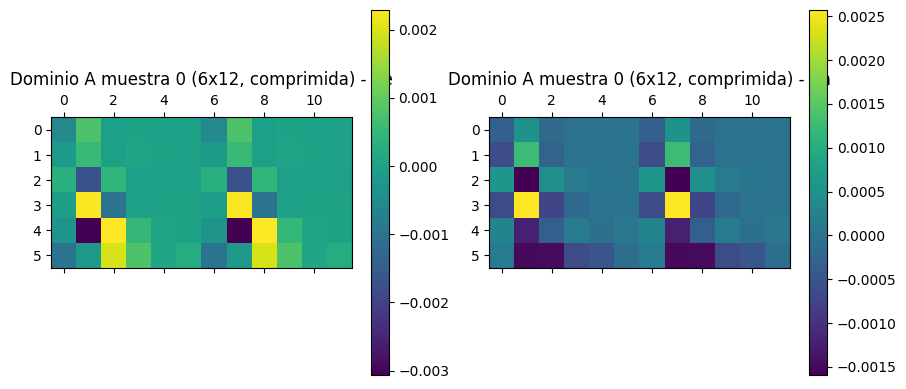

Forma: (6, 12)
OK: expand_ab_pairs(compress_ab_pairs(x)) == x


In [15]:
A_compressed_list = compress_ab_pairs_list(A_raw_list)

show_matrix(A_compressed_list[idx_ejemplo_A], title=f"Domain A sample {idx_ejemplo_A} (6x12, compressed)")
print("Shape:", A_compressed_list[idx_ejemplo_A].shape)

# Sanity check: compression must not lose or invent information.
recon = expand_ab_pairs(A_compressed_list[idx_ejemplo_A])
assert np.allclose(recon, A_raw_list[idx_ejemplo_A]), "compress/expand round-trip does not match!"
print("OK: expand_ab_pairs(compress_ab_pairs(x)) == x")

### STEP 2c -- Save the compressed domain A into a NEW .h5

In [18]:
save_compressed_dataset_h5(
    OUT_SYNTHETIC_H5,
    A_compressed_list,
    A_meta,
    freq_hz=FREQ_HZ,
    domain_name="synthetic",
    source_path=SIM_H5_PATH,
)
summarize_dataset(A_meta, "synthetic_dataset_6x12.h5")

[data_io] Guardadas 1216 muestras (synthetic) en './synthetic_dataset_6x12.h5'
--- Resumen dataset 'synthetic_dataset_6x12.h5' ---
Total de muestras: 1216
Por target_type:
  Target 1 (30x20mm): 672
  Target 2 (60x50mm): 416
  Target 3 (110x80mm): 128
Por target_eps_label:
  Hem 1  (eps = 63.69): 304
  Hem 2  (eps = 77.7): 304
  Isc 1  (eps = 37.47): 304
  Isc 2  (eps = 15.1): 304


---
## STEP 3 -- Domain B: before/after subtraction, and compression

To remove any doubt that the `target - background` subtraction has already been applied, this section explicitly shows the BEFORE (raw total field, unsubtracted, unmasked) and the AFTER (already subtracted and masked differential), for both the full matrix (12x12) and the compressed one (6x12).

### STEP 3a -- Before/after, full matrix (12x12)

- **Before**: raw `S_target` exactly as it comes out of the VNA (total field, WITHOUT subtracting the background, unmasked). Note that here the A-A/B-B blocks DO have values (switch isolation/crosstalk, not valid physical measurements).
- **After**: `dS = S_target - S_previous_healthy`, with the A<->B mask applied -- this is exactly what `load_experimental_domain` uses and what was shown in `B_raw_list[idx_ejemplo_B]`.

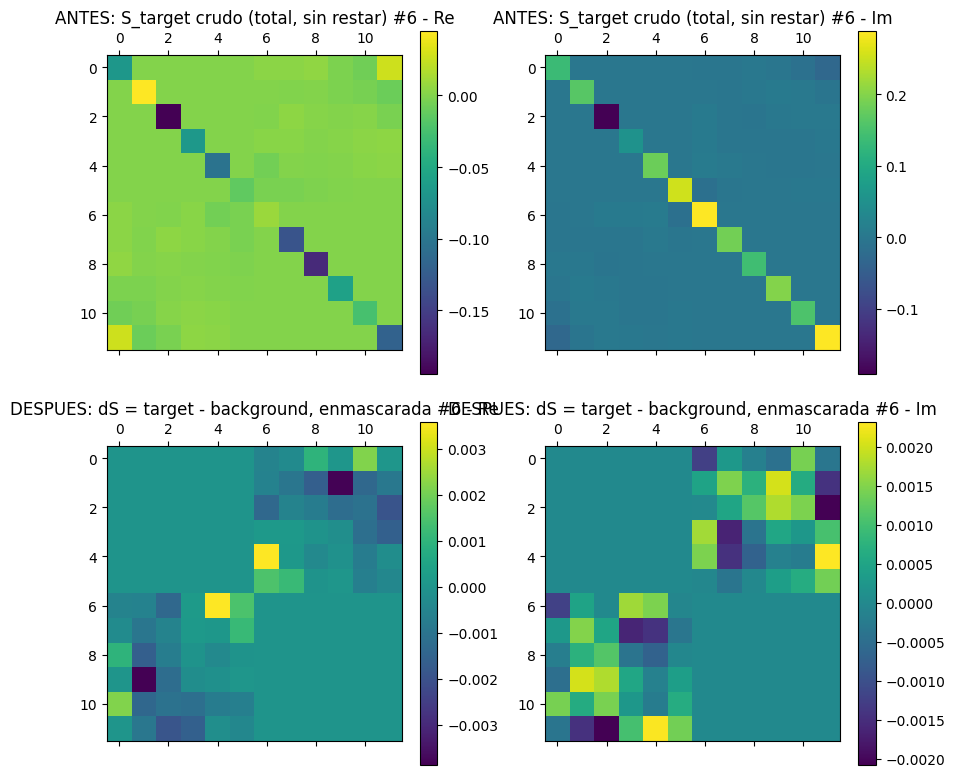

Entradas no-cero ANTES (crudo, sin mascara): 84 / 144
Entradas no-cero DESPUES (diferencial + mascara): 72 / 144 (esperado: 72)


In [16]:
S_target_raw, S_healthy_raw, dS_unmasked, dS_masked, meta_debug = get_experimental_sample_before_after(
    ROBOT_H5_PATH, FREQ_HZ, idx_ejemplo_B
)

# dS_masked must be identical to B_raw_list[idx_ejemplo_B] (same logic, same index)
assert np.allclose(dS_masked, B_raw_list[idx_ejemplo_B]), "the index does not correspond to the same sample!"

show_before_after(
    S_target_raw, dS_masked,
    label_before=f"BEFORE: raw S_target (total, unsubtracted) #{idx_ejemplo_B}",
    label_after=f"AFTER: dS = target - background, masked #{idx_ejemplo_B}",
)

print(f"Nonzero entries BEFORE (raw, unmasked): {np.sum(np.abs(S_target_raw) > 0)} / 144")
print(f"Nonzero entries AFTER (differential + mask): {np.sum(np.abs(dS_masked) > 0)} / 144 (expected: 72)")

### STEP 3b -- Before/after, compressed matrix (6x12)

`compress_ab_pairs` is applied both to the raw data (`S_target_raw`, only for visual contrast) and to the already-masked differential (`dS_masked`, what actually gets saved into the dataset).

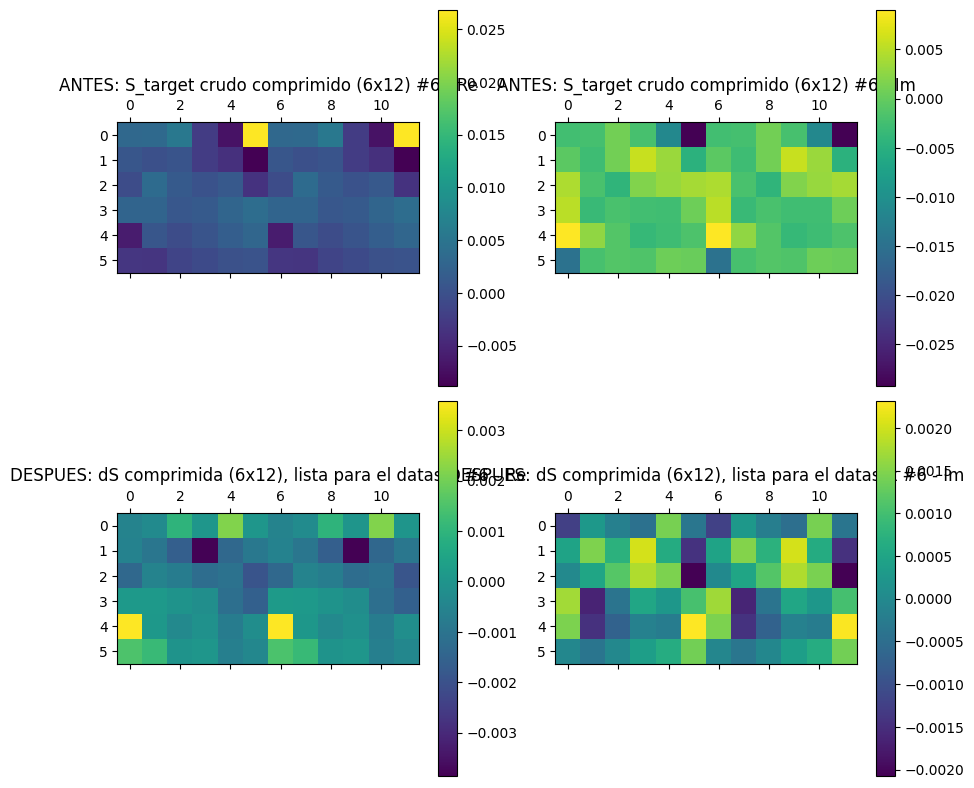

In [17]:
S_target_raw_compressed = compress_ab_pairs(S_target_raw)
dS_masked_compressed = compress_ab_pairs(dS_masked)

show_before_after(
    S_target_raw_compressed, dS_masked_compressed,
    label_before=f"BEFORE: raw S_target compressed (6x12) #{idx_ejemplo_B}",
    label_after=f"AFTER: dS compressed (6x12), ready for the dataset #{idx_ejemplo_B}",
)

### STEP 3c -- Compress the ENTIRE domain B and save into a NEW .h5

In [19]:
B_compressed_list = compress_ab_pairs_list(B_raw_list)

recon = expand_ab_pairs(B_compressed_list[idx_ejemplo_B])
assert np.allclose(recon, B_raw_list[idx_ejemplo_B]), "compress/expand round-trip does not match!"
print("OK: expand_ab_pairs(compress_ab_pairs(x)) == x")

save_compressed_dataset_h5(
    OUT_EXPERIMENTAL_H5,
    B_compressed_list,
    B_meta,
    freq_hz=FREQ_HZ,
    domain_name="experimental",
    source_path=ROBOT_H5_PATH,
)
summarize_dataset(B_meta, "experimental_dataset_6x12.h5")

OK: expand_ab_pairs(compress_ab_pairs(x)) == x
[data_io] Guardadas 1239 muestras (experimental) en './experimental_dataset_6x12.h5'
--- Resumen dataset 'experimental_dataset_6x12.h5' ---
Total de muestras: 1239
Por target_type:
  Target 1 (30×20mm): 677
  Target 2 (60×50mm): 434
  Target 3 (110×80mm): 128
Por target_eps_label:
  Hem 1  (eps = 52.0): 325
  Hem 2  (eps = 58.0): 306
  Isc 1  (eps = 72.0): 304
  Isc 2  (eps = 80.0): 304


---
## STEP 4 -- Final check: re-read the new .h5 files and compare magnitudes

Quick check that both domains, now compressed, ended up in a comparable magnitude range (important for normalization before training the Cycle-GAN), plus a final summary of how many samples each new dataset has.

=== Conteo final de muestras en los .h5 nuevos ===
synthetic_dataset_6x12.h5    : 1216 muestras, forma por muestra (6, 12)
experimental_dataset_6x12.h5 : 1239 muestras, forma por muestra (6, 12)

Dominio A: |x| medio = 2.3640e-03
Dominio B: |x| medio = 1.5189e-03


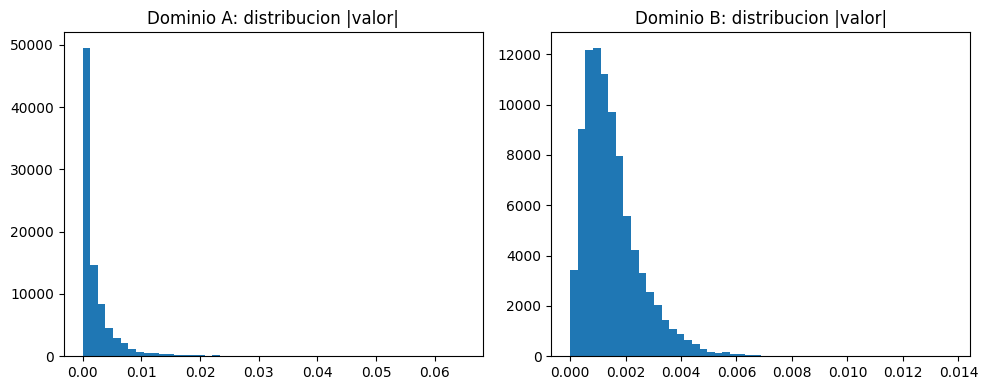

In [20]:
from data_io import load_compressed_dataset_h5

A_check, A_meta_check, freq_A = load_compressed_dataset_h5(OUT_SYNTHETIC_H5)
B_check, B_meta_check, freq_B = load_compressed_dataset_h5(OUT_EXPERIMENTAL_H5)

A_arr = np.array(A_check)  # (N, 6, 12)
B_arr = np.array(B_check)

print("=== Final sample count in the new .h5 files ===")
print(f"synthetic_dataset_6x12.h5    : {A_arr.shape[0]} samples, shape per sample {A_arr.shape[1:]}")
print(f"experimental_dataset_6x12.h5 : {B_arr.shape[0]} samples, shape per sample {B_arr.shape[1:]}")
print()
print(f"Domain A: mean |x| = {np.mean(np.abs(A_arr)):.4e}")
print(f"Domain B: mean |x| = {np.mean(np.abs(B_arr)):.4e}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(np.abs(A_arr).flatten(), bins=50)
ax[0].set_title("Domain A: |value| distribution")
ax[1].hist(np.abs(B_arr).flatten(), bins=50)
ax[1].set_title("Domain B: |value| distribution")
fig.tight_layout()
plt.show()

With `synthetic_dataset_6x12.h5` and `experimental_dataset_6x12.h5` generated, the training scripts in `training/` read these two compact 6x12 files directly (instead of the original 12x12 `.h5` files), with `img_shape` and the generator depth already adjusted for this shape (`gen_depth=2`, since 6 is not divisible by 4).